In [1]:
# import pandas as pd
# pd.read_csv('../working-vars/Y_gmm_20250717.csv', index_col=0)

In [ ]:
import os
import numpy as np
import pandas as pd
import xarray as xr
from importlib import reload

import mod_loading as loader
import figs_pcm 

In [3]:
# Import data
reload(loader)
Y_gmm = pd.read_csv('../working-vars/pcm/Y_gmm_20250717.csv', index_col=0) # Results of GMM
[coreDS, coreINDEX, bgcDS, bgcINDEX, socat] = loader.import_data(type=['core', 'bgc', 'socat'])

## SOCAT

In [4]:
path = '/Volumes/cremas-repo/data/socat/colocate-coreArgo/'

sepdict_7d = {key:None for key in [str(x) for x in range(2014,2024)]}

for x in os.listdir(path):
    if x.startswith('colocate_7d') & x.endswith('.csv'):
        sepdict_7d[x[14:18]] = pd.read_csv(path+x, index_col=0)
        # print('Imported data for _7d window: ' + x)

sepstat_7d = pd.concat(sepdict_7d.values()).reset_index().drop(['level_0', 'index'], axis=1)
sepstat_7d.tail()


socat_df = sepstat_7d[sepstat_7d['latitude']<-35].reset_index()

In [5]:
# socat_df = socat.to_dataframe()
socat_df.head()

,index,longitude,latitude,fco2rec,sal,sst,yearday,fco2water_equ_wet,fco2water_sst_wet,pco2water_equ_wet,...,xco2water_sst_dry,datetime,expoID,bathymetry,nearest_profid,prof_datetime,prof_lat,prof_lon,yd_sep,km_sep
0,0,-15.80955,-71.79225,395.3360,34.291,-1.1240,0.550405,NaN,395.40,NaN,...,NaN,2014-01-01 13:12:35,06AQ20131221_id0,-1462,5903614_id108,2014-01-06,-69.51,-16.14,4.923681,254.065485
1,1,-17.01550,-72.06460,395.7800,34.258,-1.0810,0.689988,NaN,395.80,NaN,...,NaN,2014-01-01 16:33:35,06AQ20131221_id0,-1762,5903614_id108,2014-01-06,-69.51,-16.14,4.784097,285.851670
2,2,-18.14250,-72.45300,396.9780,34.260,-1.1370,0.826539,NaN,396.95,NaN,...,NaN,2014-01-01 19:50:13,06AQ20131221_id0,-1896,5903614_id108,2014-01-06,-69.51,-16.14,4.647546,335.148754
3,3,-20.30105,-72.96715,392.1685,34.231,-1.4555,1.048368,NaN,392.15,NaN,...,NaN,2014-01-02 01:09:39,06AQ20131221_id0,-2186,5903614_id108,2014-01-06,-69.51,-16.14,4.425718,411.985622
4,4,-21.49620,-73.26000,365.1670,34.076,-1.3310,1.177130,NaN,365.20,NaN,...,NaN,2014-01-02 04:15:04,06AQ20131221_id0,-1794,5903614_id108,2014-01-06,-69.51,-16.14,4.296956,457.863463


In [6]:
# === Separate socat data by class

# socat_df = sepstat_7d[sepstat_7d['latitude']<-35].reset_index()
for ind in range(len(socat_df)):
    try:
        socat_df.loc[ind,  'class'] = int(Y_gmm.loc[socat_df.loc[ind, 'nearest_profid'], 'class'])
    except:
        socat_df.loc[ind,  'class'] = None

# Make dictionary
socat_classes = {k:None for k in range(8)}
for ind in range(8):
    socat_classes[ind] = socat_df[socat_df['class']==ind]

In [27]:
socat_df

,index,longitude,latitude,fco2rec,sal,sst,yearday,fco2water_equ_wet,fco2water_sst_wet,pco2water_equ_wet,...,datetime,expoID,bathymetry,nearest_profid,prof_datetime,prof_lat,prof_lon,yd_sep,km_sep,class
0,0,-15.80955,-71.792250,395.3360,34.2910,-1.1240,0.550405,NaN,395.400,NaN,...,2014-01-01 13:12:35,06AQ20131221_id0,-1462,5903614_id108,2014-01-06,-69.5100,-16.1400,4.923681,254.065485,2.0
1,1,-17.01550,-72.064600,395.7800,34.2580,-1.0810,0.689988,NaN,395.800,NaN,...,2014-01-01 16:33:35,06AQ20131221_id0,-1762,5903614_id108,2014-01-06,-69.5100,-16.1400,4.784097,285.851670,2.0
2,2,-18.14250,-72.453000,396.9780,34.2600,-1.1370,0.826539,NaN,396.950,NaN,...,2014-01-01 19:50:13,06AQ20131221_id0,-1896,5903614_id108,2014-01-06,-69.5100,-16.1400,4.647546,335.148754,2.0
3,3,-20.30105,-72.967150,392.1685,34.2310,-1.4555,1.048368,NaN,392.150,NaN,...,2014-01-02 01:09:39,06AQ20131221_id0,-2186,5903614_id108,2014-01-06,-69.5100,-16.1400,4.425718,411.985622,2.0
4,4,-21.49620,-73.260000,365.1670,34.0760,-1.3310,1.177130,NaN,365.200,NaN,...,2014-01-02 04:15:04,06AQ20131221_id0,-1794,5903614_id108,2014-01-06,-69.5100,-16.1400,4.296956,457.863463,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44138,49989,173.90860,-42.846830,336.0260,34.8500,11.9960,3575.687153,338.56,335.590,NaN,...,2023-10-16 16:29:30,PAT520231011_id1,-1293,5906268_id115,2023-10-17,-46.0400,174.6480,0.818206,359.878720,NaN
44139,49990,171.88920,-38.184585,345.0050,35.3520,15.4715,3584.596875,347.32,344.480,NaN,...,2023-10-25 14:19:30,PAT520231025_id0,-1515,5905206_id229,2023-10-23,-36.0994,169.4027,1.856852,319.872125,4.0
44140,49991,171.52895,-37.566470,353.0200,35.3815,15.7540,3584.687153,355.36,352.530,NaN,...,2023-10-25 16:29:30,PAT520231025_id0,-1784,5905206_id229,2023-10-23,-36.0994,169.4027,1.947130,249.828814,4.0
44141,49992,170.91705,-36.760095,362.2510,35.3635,16.0285,3584.812153,364.52,361.775,NaN,...,2023-10-25 19:29:30,PAT520231025_id0,-2052,5905206_id229,2023-10-23,-36.0994,169.4027,2.072130,154.116392,4.0


In [32]:
xr.Dataset.from_dataframe(socat_classes[0])

<xarray.Dataset>
Dimensions:            (index: 2354)
Coordinates:
  * index              (index) int64 156 157 158 159 ... 49857 49858 49887 49888
Data variables: (12/23)
    longitude          (index) float64 13.54 13.61 13.71 ... 174.4 174.7 174.2
    latitude           (index) float64 -45.97 -45.8 -45.57 ... -42.28 -42.64
    fco2rec            (index) float64 378.1 378.3 378.4 ... 371.9 310.1 315.0
    sal                (index) float64 33.75 33.76 33.81 ... 34.67 35.52 35.52
    sst                (index) float64 7.507 7.847 8.062 ... 17.91 15.06 15.1
    yearday            (index) float64 57.59 57.67 57.8 ... 3.391e+03 3.391e+03
    ...                 ...
    prof_datetime      (index) object '2014-03-04' '2014-03-04' ... '2023-04-09'
    prof_lat           (index) float64 -44.43 -44.43 -44.43 ... -42.23 -42.23
    prof_lon           (index) float64 12.96 12.96 12.96 ... 175.8 176.0 176.0
    yd_sep             (index) float64 5.231 5.147 5.022 ... 4.356 4.927 4.995
    km_sep             (index) float64 176.8 160.4 140.0 ... 116.7 104.4 153.2
    class              (index) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [86]:
# Good version, Aug 5 2025 
list = []
for class_id, ds in socat_classes.items():
    # Create a new coordinate 'class' for each profile
    temp_ds = (xr.Dataset.from_dataframe(socat_classes[class_id].set_index('index'))
    )
    list.append(temp_ds.assign_coords(cluster = temp_ds['class']+1))

# Merge all classes along profid
clustered_socat_ds = xr.concat(list, dim="index")
clustered_socat_ds

<xarray.Dataset>
Dimensions:            (index: 42459)
Coordinates:
  * index              (index) int64 156 157 158 159 ... 49618 49619 49620 49621
    cluster            (index) float64 1.0 1.0 1.0 1.0 1.0 ... 8.0 8.0 8.0 8.0
Data variables: (12/23)
    longitude          (index) float64 13.54 13.61 13.71 ... 171.6 171.6 171.6
    latitude           (index) float64 -45.97 -45.8 -45.57 ... -46.92 -46.94
    fco2rec            (index) float64 378.1 378.3 378.4 ... 377.3 377.9 370.8
    sal                (index) float64 33.75 33.76 33.81 ... 34.43 34.42 34.47
    sst                (index) float64 7.507 7.847 8.062 ... 15.4 15.37 15.78
    yearday            (index) float64 57.59 57.67 57.8 ... 3.356e+03 3.356e+03
    ...                 ...
    prof_datetime      (index) object '2014-03-04' '2014-03-04' ... '2023-03-05'
    prof_lat           (index) float64 -44.43 -44.43 -44.43 ... -50.49 -50.49
    prof_lon           (index) float64 12.96 12.96 12.96 ... 176.4 176.4 176.4
    yd_sep             (index) float64 5.231 5.147 5.022 ... 5.457 5.566 5.686
    km_sep             (index) float64 176.8 160.4 140.0 ... 525.6 526.1 524.5
    class              (index) float64 0.0 0.0 0.0 0.0 0.0 ... 7.0 7.0 7.0 7.0

In [ ]:
if save:
    clustered_socat_ds.to_netcdf('../working-vars/pcm/clustered_socat_output.nc')

In [7]:
for ind in range(8):
    print(f'Class {ind+1}: {len(socat_classes[ind].index.values)}')

Class 1: 2354
Class 2: 5965
Class 3: 8190
Class 4: 3644
Class 5: 8286
Class 6: 1622
Class 7: 11852
Class 8: 546


<GeoAxes: >

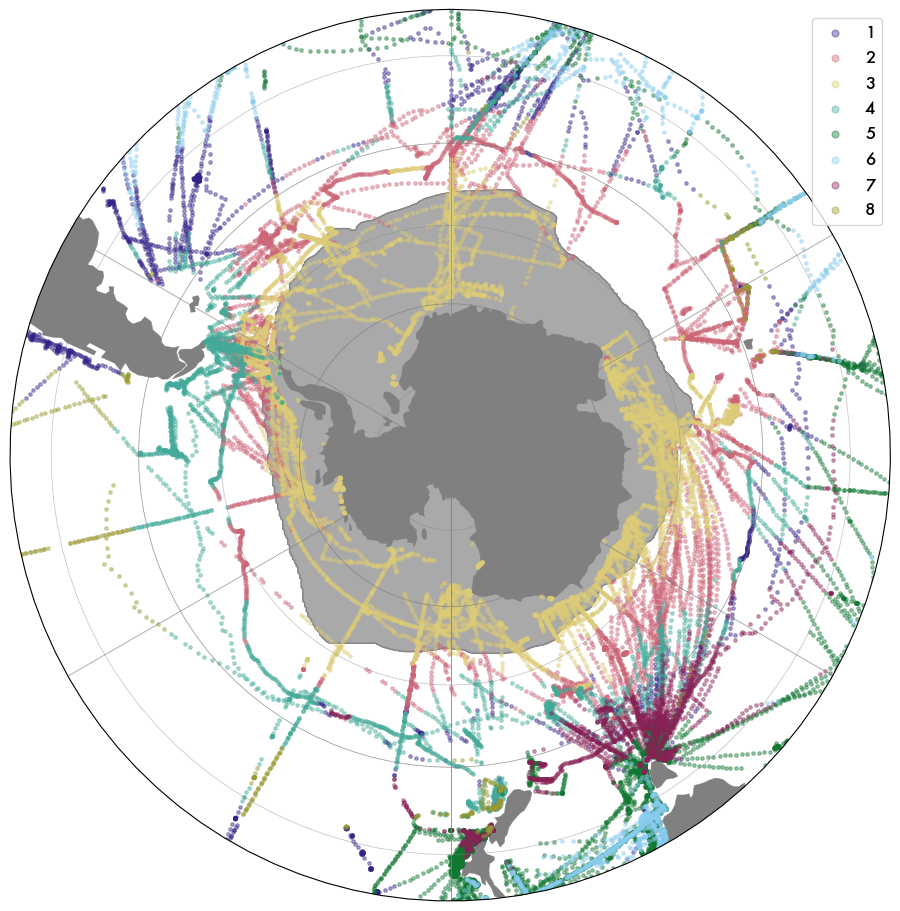

In [8]:
reload(figs_pcm)

# To plot all classes on one plot
figs_pcm.sopolar_classes(socat_classes, inds=range(8), figsize=(9,9), dotsize=6, markerscale=2)

## bgcArgo



In [9]:
bgcDS
# bgcINDEX.sel(profid=bgcDS.profid.values)

<xarray.Dataset>
Dimensions:      (profid: 11749, pressure: 197)
Coordinates:
  * profid       (profid) object '2903453_id001' ... '6903026_id097'
  * pressure     (pressure) int64 0 5 10 15 20 25 30 ... 955 960 965 970 975 980
    yearday      (profid, pressure) float64 ...
    latitude     (profid, pressure) float64 ...
    longitude    (profid, pressure) float64 ...
    wmoid        (profid, pressure) float64 ...
    datetime     (profid, pressure) datetime64[ns] ...
Data variables:
    CT           (profid, pressure) float64 ...
    SA           (profid, pressure) float64 ...
    sigma0       (profid, pressure) float64 ...
    spice        (profid, pressure) float64 ...
    temperature  (profid, pressure) float64 ...
    salinity     (profid, pressure) float64 ...
    pH           (profid, pressure) float64 ...
    oxygen       (profid, pressure) float64 ...
Attributes:
    title:            BGC float profiles with valid data, interpolated to n=2...
    pressure_levels:  Pressure levels in dbar: [0, 5, 10, 15, 20, 25, 30, 35,...
    source:           Argopy, expert mode
    date:             20250729

In [10]:
# === Separate bgc data by class
bgc_df = bgcINDEX.to_dataframe()

for ind in bgc_df.index:
    try:
        bgc_df.loc[ind,  'class'] = int(Y_gmm.loc[ind, 'class'])
    except:
        bgc_df.loc[ind,  'class'] = None

# Make dictionary
bgc_classes = {k:None for k in range(8)}
for ind in range(8):
    # bgc_classes[ind] = bgc_df[bgc_df['class']==ind]
    bgc_classes[ind] = bgcDS.sel({'profid':[x for x in bgc_df[bgc_df['class']==ind].index]})

In [11]:
import xarray as xr

In [14]:
import xarray as xr

In [15]:
list = []
for class_id, ds in bgc_classes.items():
    # Create a new coordinate 'class' for each profile
    ds_with_class = ds.assign_coords(cluster = (ds.yearday * 0 + class_id + 1))
    list.append(ds_with_class)

# Merge all classes along profid
merged_ds = xr.concat(list, dim="profid")

/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/p

In [16]:
merged_ds

<xarray.Dataset>
Dimensions:      (profid: 11346, pressure: 197)
Coordinates:
  * profid       (profid) object '2903456_id018' ... '5906567_id015'
  * pressure     (pressure) int64 0 5 10 15 20 25 30 ... 955 960 965 970 975 980
    yearday      (profid, pressure) float64 3.622e+03 3.622e+03 ... 3.391e+03
    latitude     (profid, pressure) float64 -54.48 -54.48 ... -44.81 -44.81
    longitude    (profid, pressure) float64 -143.3 -143.3 ... -165.0 -165.0
    wmoid        (profid, pressure) float64 2.903e+06 2.903e+06 ... 5.907e+06
    datetime     (profid, pressure) datetime64[ns] 2023-12-01T21:53:59 ... 20...
    cluster      (profid, pressure) float64 1.0 1.0 1.0 1.0 ... 8.0 8.0 8.0 8.0
Data variables:
    CT           (profid, pressure) float64 6.84 6.84 6.839 ... 6.116 6.086
    SA           (profid, pressure) float64 34.08 34.08 34.08 ... 34.51 34.51
    sigma0       (profid, pressure) float64 26.59 26.59 26.59 ... 27.03 27.03
    spice        (profid, pressure) float64 -0.04522 -0.04522 ... 0.1647 0.1603
    temperature  (profid, pressure) float64 6.833 6.833 6.833 ... 6.205 6.175
    salinity     (profid, pressure) float64 33.92 33.92 33.92 ... 34.35 34.35
    pH           (profid, pressure) float64 8.006 8.006 8.005 ... 7.887 7.887
    oxygen       (profid, pressure) float64 301.1 301.1 301.0 ... 220.9 220.1
Attributes:
    title:            BGC float profiles with valid data, interpolated to n=2...
    pressure_levels:  Pressure levels in dbar: [0, 5, 10, 15, 20, 25, 30, 35,...
    source:           Argopy, expert mode
    date:             20250729

In [22]:
merged_ds.to_netcdf('../working-vars/pcm/clustered_bgcArgo.nc')

In [17]:
from matplotlib import pyplot as plt

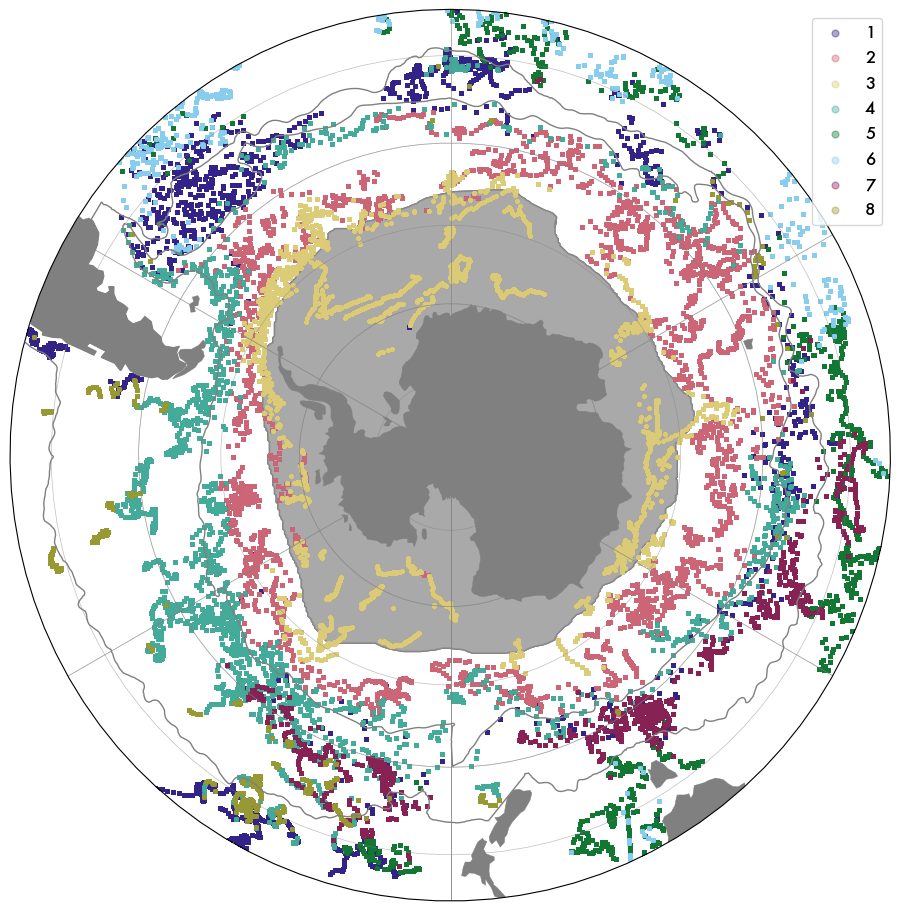

In [18]:
reload(figs_pcm)

# To plot all classes on one plot
ax = figs_pcm.sopolar_classes(bgc_classes, inds=range(8), 
                         figsize=(9,9), 
                         dotsize=6, markerscale=2)

# figs_pcm.sopolar_classes(socat_classes, inds=range(8), 
#                          ax=ax, figsize=(9,9), 
#                          dotsize=6, markerscale=2, legend=False)

# ax.set_title('BGC and SOCAT data')

import mod_southpolarplot as sopo
sopo.add_frontlines(ax, types=['saf', 'stf'])

In [19]:
# Compare number of training obs for each class
nobs_table = pd.DataFrame(index = range(8))
for ind in range(8):
    nobs_table.loc[ind, 'socat'] = int(len(socat_classes[ind].index.values))
    nobs_table.loc[ind, 'bgc'] = int(len(bgc_classes[ind].profid.values))
    
nobs_table['total_training'] = nobs_table['socat'] + nobs_table['bgc']
nobs_table.index=range(1,9)
nobs_table

,socat,bgc,total_training
1,2354.0,1415.0,3769.0
2,5965.0,2502.0,8467.0
3,8190.0,2787.0,10977.0
4,3644.0,2063.0,5707.0
5,8286.0,936.0,9222.0
6,1622.0,366.0,1988.0
7,11852.0,885.0,12737.0
8,546.0,392.0,938.0


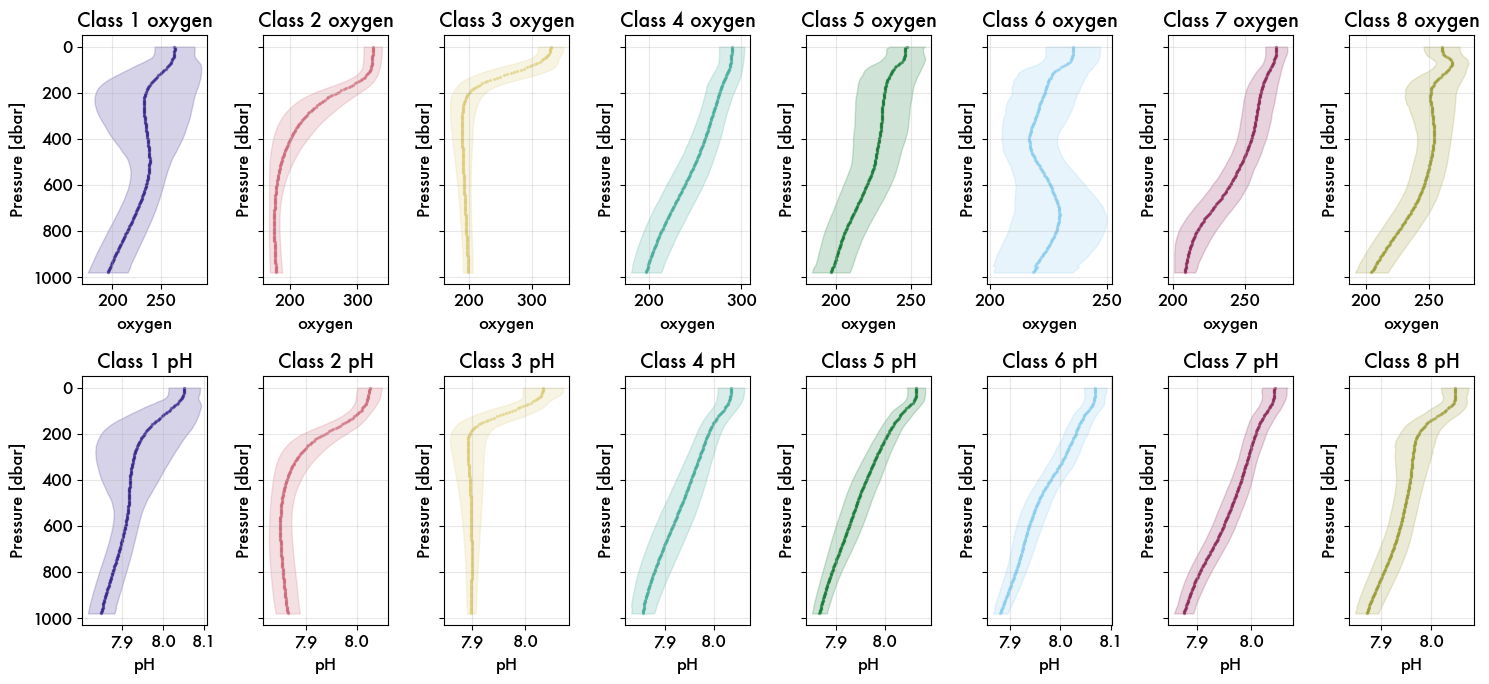

In [20]:
reload(figs_pcm)
figs_pcm.mean_tracer_profiles_paneled(bgc_classes, vars = ['oxygen', 'pH'],
                                 figsize = (15,7))